Problem statement: Understand the reasons for income of human beings in the dataset being <=50k or >50k

## Import libraries

In [ ]:
## Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns

## Upload dataset

In [ ]:
df = pd.read_csv('/content/Humans dataset.csv')

## Basic data inspection

In [ ]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [ ]:
## Check the shape of the dataset

df.shape

(32561, 15)

In [ ]:
## Check the basic info of the dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   gender          32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
## Basic statistical analysis

df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## Null value check

In [ ]:
## Check null values in the dataset

df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
gender,0


## Duplicates check

In [ ]:
## Duplicates check

df.duplicated().sum()

np.int64(24)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(32537, 15)

## Split the data into categorical and numerical columns

In [ ]:


categorical_columns = df.select_dtypes(include = 'object').columns
numerical_columns = df.select_dtypes(exclude = 'object').columns

In [ ]:
categorical_columns

Index(['workclass', 'education', 'marital.status', 'occupation',
       'relationship', 'race', 'gender', 'native.country', 'income'],
      dtype='object')

In [ ]:
numerical_columns

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

In [ ]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [ ]:
## Count the values in each of the categories

for i in categorical_columns:
  print(df[i].value_counts())
  print('--'*50)

workclass
Private             22673
Self-emp-not-inc     2540
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
education
HS-grad         10494
Some-college     7282
Bachelors        5353
Masters          1722
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           645
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           332
1st-4th           166
Preschool          50
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------
marital.status
Married-civ-spouse       14970
Never-married            10667
Divorced                  4441
Separated                 1025
W

## Handling error "?" values in the dataset

In [ ]:
## Find out how many "?" are there in any columns

df.isin(['?']).sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
gender,0


In [ ]:
## replace all "?" values with Null values

df.replace('?', np.nan, inplace= True)

In [ ]:
## Find out how many "?" are there in any columns

df.isin(['?']).sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
gender,0


In [ ]:
## Lets recheck the null values

df.isnull().sum()

,0
age,0
workclass,1836
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,1843
relationship,0
race,0
gender,0


In [ ]:
df['native.country'].mode()[0]

'United-States'

In [ ]:
df['occupation'].mode()[0]

'Prof-specialty'

In [ ]:
for col in ['workclass', 'native.country', 'occupation']:
  df[col].fillna(df[col].mode()[0], inplace=True)

In [ ]:
## Lets recheck the null values

df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
gender,0


## Univariate analysis

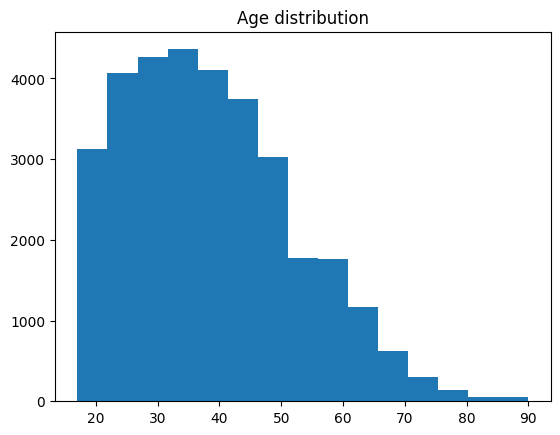

In [ ]:
## Age distribution

plt.hist(df["age"], bins= 15)
plt.title("Age distribution")
plt.show()

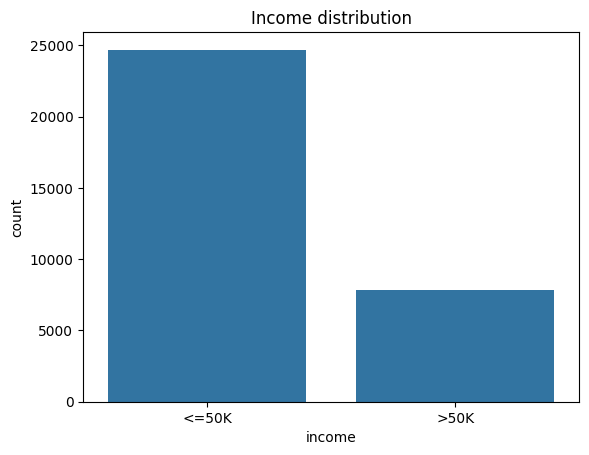

In [ ]:
## Income distribution

sns.countplot(x = "income", data = df)
plt.title("Income distribution")
plt.show()

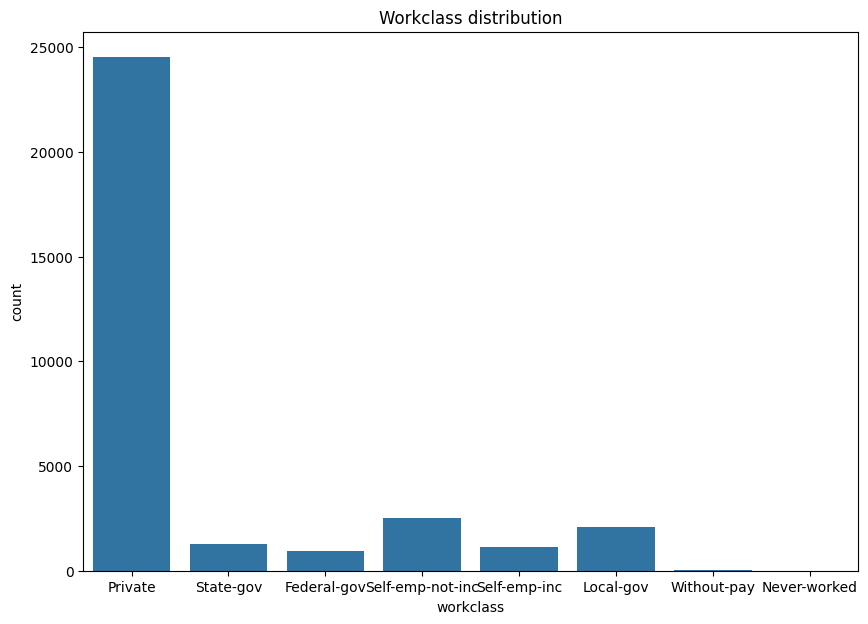

In [ ]:
## Workclass distribution

plt.figure(figsize = (10, 7))
sns.countplot(x = "workclass", data = df)
plt.title("Workclass distribution")
plt.show()

## Bivariate analysis

In [ ]:
numerical = df.select_dtypes(exclude = 'object')

In [ ]:
numerical

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
0,90,77053,9,0,4356,40
1,82,132870,9,0,4356,18
2,66,186061,10,0,4356,40
3,54,140359,4,0,3900,40
4,41,264663,10,0,3900,40
...,...,...,...,...,...,...
32556,22,310152,10,0,0,40
32557,27,257302,12,0,0,38
32558,40,154374,9,0,0,40
32559,58,151910,9,0,0,40


In [ ]:
numerical.corr()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
age,1.000000,-0.076447,0.036224,0.077676,0.057745,0.068515
fnlwgt,-0.076447,1.000000,-0.043388,0.000429,-0.010260,-0.018898
education.num,0.036224,-0.043388,1.000000,0.122664,0.079892,0.148422
capital.gain,0.077676,0.000429,0.122664,1.000000,-0.031639,0.078408
capital.loss,0.057745,-0.010260,0.079892,-0.031639,1.000000,0.054229
hours.per.week,0.068515,-0.018898,0.148422,0.078408,0.054229,1.000000


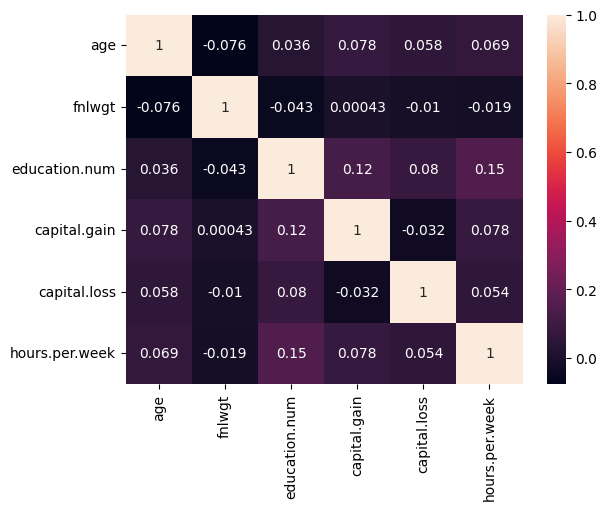

In [ ]:
## Correlation

sns.heatmap(numerical.corr(), annot = True)
plt.show()

## Outlier detection:

1. Detect the outliers: boxplot, histogram
2. Remove the outliers:
* a. IQR (boxplot method)
* b. Z-score method





In [ ]:
numerical_columns

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

### 1. Box plot(IQR) method

In [ ]:
outliers_iqr = {}

In [ ]:
for col in numerical_columns:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3 - Q1

  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

  df_iqr = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

  outliers_iqr[col] = len(outliers)

  print("Original Shape: ", df.shape)
  print("New Shape: ", df_iqr.shape)
  print("--"*50)

Original Shape:  (32537, 15)
New Shape:  (32395, 15)
----------------------------------------------------------------------------------------------------
Original Shape:  (32537, 15)
New Shape:  (31544, 15)
----------------------------------------------------------------------------------------------------
Original Shape:  (32537, 15)
New Shape:  (31344, 15)
----------------------------------------------------------------------------------------------------
Original Shape:  (32537, 15)
New Shape:  (29825, 15)
----------------------------------------------------------------------------------------------------
Original Shape:  (32537, 15)
New Shape:  (31018, 15)
----------------------------------------------------------------------------------------------------
Original Shape:  (32537, 15)
New Shape:  (23535, 15)
----------------------------------------------------------------------------------------------------


### Z-score method for outliers

#### Reload the dataset, then only proceed with the z-score method for outlier removal

In [ ]:
numerical_columns

Index(['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss',
       'hours.per.week'],
      dtype='object')

In [ ]:
from scipy import stats

In [ ]:
z_score = np.abs(stats.zscore(df[numerical_columns]))

In [ ]:
z_score

array([[ 3.77000319,  1.06795519,  0.42067868,  0.14597544, 10.5896253 ,
         0.03566374],
       [ 3.18339719,  0.53915902,  0.42067868,  0.14597544, 10.5896253 ,
         1.81751646],
       [ 2.01018519,  0.03524091,  0.03181473,  0.14597544, 10.5896253 ,
         0.03566374],
       ...,
       [ 0.1037157 ,  0.33543555,  0.42067868,  0.14597544,  0.21674317,
         0.03566374],
       [ 1.42357919,  0.35877886,  0.42067868,  0.14597544,  0.21674317,
         0.03566374],
       [ 1.2161478 ,  0.11092955,  0.42067868,  0.14597544,  0.21674317,
         1.65552985]])

In [ ]:
outliers = (z_score > 3).any(axis = 1) | (z_score < -3).any(axis = 1)

print("Number of outliers using Z-score: ", len(df[outliers]))

Number of outliers using Z-score:  2728


In [ ]:
## Removal of outliers using Z-score

df_zscore = df[(z_score < 3).all(axis=1)]

print("Original shape: ", df.shape)
print("New shape: ", df_zscore.shape)

Original shape:  (32537, 15)
New shape:  (29809, 15)


In [ ]:
df_zscore

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,gender,capital.gain,capital.loss,hours.per.week,native.country,income
1470,62,Local-gov,159908,Bachelors,13,Married-civ-spouse,Adm-clerical,Wife,White,Female,0,1258,38,United-States,<=50K
1471,72,Local-gov,144515,Doctorate,16,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,1258,40,United-States,<=50K
1472,76,?,224680,Prof-school,15,Married-civ-spouse,?,Husband,White,Male,0,1258,20,United-States,<=50K
1473,66,Private,350498,Some-college,10,Married-civ-spouse,Transport-moving,Husband,White,Male,0,1258,20,United-States,<=50K
1474,33,Local-gov,262042,HS-grad,9,Divorced,Adm-clerical,Own-child,White,Female,0,1138,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
